# تشخیص نوع عیب ورق فولادی (Steel Plate Fault Type Classification)
## خط لوله نهایی، آموزش، ارزیابی متوازن، انتخاب ویژگی ژنتیکی و ممیزی نشت داده

| نقش | نام | GitHub |
| :--- | :--- | :--- |
| **مدیر** | Melina Salemi | [@s-melina](https://github.com/s-melina) |
| **معمار** | Kiana Sarkari | [@kia-kiio](https://github.com/kia-kiio) |
| **تحلیلگر** | Marvel Keshtkar | [@Marvel200123](https://github.com/Marvel200123) |

---
### خلاصه اجرایی معماری (Executive Summary)
این نوت‌بوک جریان کامل، مستقل و تجدیدپذیر پروژه تشخیص نوع عیب ورق فولادی را بر روی دیتاست مرجع **UCI Steel Plates Faults** (با ۱٬۹۴۱ نمونه، ۲۷ ویژگی مستقل و ۷ کلاس عیب) پیاده‌سازی می‌کند.
کلیه مراحل اعم از اعتبارسنجی کیفیت داده، تبدیل هدف One-Hot، ممیزی عدم نشت، تحلیل آماری، فیلتر همبستگی، بهینه‌سازی فراابتکاری الگوریتم ژنتیک با ۳ دانه تصادفی، تثبیت پایپ‌لاین نهایی و در نهایت **ارزیابی تک‌باره روی مجموعه Test دست‌نخورده** با فراخوانی ماژول‌های معماری پکیج `src` به صورت انتها-به-انتها اجرا می‌شوند.


In [1]:
import os
import sys
import json
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting setup
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']

# Set project-relative path resolution
NOTEBOOK_DIR = Path.cwd()
ROOT_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
SRC_DIR = ROOT_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Import modular project architecture
import utils
from utils import FEATURE_NAMES, CLASSES, RAW_TARGET_COLS, set_seed
import data_loader
import data_validation
import preprocessing
import feature_selection
import genetic_feature_selection
import models
import tuning
import noise_analysis
import evaluation

print(f"Project Root: {ROOT_DIR}")
print(f"Modules imported successfully from: {SRC_DIR}")


Project Root: /mnt/data/audit2/unzip/data-analysis_project4
Modules imported successfully from: /mnt/data/audit2/unzip/data-analysis_project4/src


## ۳. پیکربندی بازتولیدپذیری و دانه‌های تصادفی (Reproducibility Configuration)
برای تضمین تکرارپذیری دقیق در تمام محیط‌ها، دانه‌های تصادفی مطابق مستند معماری تثبیت می‌شوند:
- **Global / Partition Seed**: `42`
- **Hyperparameter Search Seed**: `2026`
- **Genetic Algorithm Seeds**: `11`, `22`, `33`
- **CV Seed**: `123`


In [2]:
GLOBAL_SEED = 42
set_seed(GLOBAL_SEED)
print(f"Global random seed locked to: {GLOBAL_SEED}")


Global random seed locked to: 42


## ۴. بارگذاری داده‌های خام و بررسی ابعاد (Dataset Ingestion)
داده‌های خام دست‌نخورده از مسیر `data/raw/` بارگذاری شده و تعداد سطرها و ستون‌ها بررسی می‌شوند.


In [3]:
raw_df, feature_names, target_names = data_loader.load_raw_data()

print(f"Loaded Raw Dataset: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")
print(f"Independent Features Count: {len(feature_names)}")
print(f"Raw Target Columns Count: {len(target_names)}")

# Verification assertions
assert raw_df.shape == (1941, 34), f"Unexpected raw shape: {raw_df.shape}"
assert len(feature_names) == 27, f"Feature count must be 27, got {len(feature_names)}"
assert len(target_names) == 7, f"Target count must be 7, got {len(target_names)}"
print("[PASS] Dataset dimension requirements validated dynamically.")


Loaded Raw Dataset: 1941 rows, 34 columns
Independent Features Count: 27
Raw Target Columns Count: 7
[PASS] Dataset dimension requirements validated dynamically.


## ۵. فرهنگ داده و شناسنامه ویژگی‌ها (Data Dictionary)
شناسنامه کامل آماری و تعاریف رسمی ۲۷ ویژگی و ۷ متغیر هدف تولید و اعتبارسنجی می‌شود.


In [4]:
dict_df = data_validation.generate_data_dictionary(raw_df)
print(f"Data Dictionary contains {len(dict_df)} validated entries:")
display(dict_df[['column', 'role', 'feature_type', 'min', 'mean', 'max', 'missing_count', 'unique_count']].head(10))


Data Dictionary contains 34 validated entries:


,column,role,feature_type,min,mean,max,missing_count,unique_count
0,X_Minimum,feature,Integer,0.0,5.711360e+02,1705.0,0,962
1,X_Maximum,feature,Integer,4.0,6.179645e+02,1713.0,0,994
2,Y_Minimum,feature,Integer,6712.0,1.650685e+06,12987661.0,0,1939
3,Y_Maximum,feature,Integer,6724.0,1.650739e+06,12987692.0,0,1940
4,Pixels_Areas,feature,Integer,2.0,1.893878e+03,152655.0,0,920
5,X_Perimeter,feature,Integer,2.0,1.118552e+02,10449.0,0,399
6,Y_Perimeter,feature,Integer,1.0,8.296600e+01,18152.0,0,317
7,Sum_of_Luminosity,feature,Integer,250.0,2.063121e+05,11591414.0,0,1909
8,Minimum_of_Luminosity,feature,Integer,0.0,8.454869e+01,203.0,0,161
9,Maximum_of_Luminosity,feature,Integer,37.0,1.301937e+02,253.0,0,100


## ۶. کنترل کیفیت داده و بررسی مقادیر گمشده و تکراری (Data Quality Validation)
داده‌ها از منظر سطور تکراری و مقادیر مفقوده ارزیابی می‌شوند.


In [5]:
missing_count = int(raw_df.isna().sum().sum())
duplicate_count = int(raw_df.duplicated().sum())

print(f"Total Missing Values: {missing_count}")
print(f"Total Duplicate Rows: {duplicate_count}")

assert missing_count == 0, "Missing values found!"
assert duplicate_count == 0, "Duplicate rows found!"
print("[PASS] Data quality check: Zero missing values and zero duplicate rows.")


Total Missing Values: 0
Total Duplicate Rows: 0
[PASS] Data quality check: Zero missing values and zero duplicate rows.


## ۷. اعتبارسنجی متغیر هدف One-Hot و تبدیل به چندکلاسه (Target Validation & Conversion)
مجموع سطرهای ۷ ستون هدف بررسی می‌شود تا اطمینان حاصل شود هر سطر دقیقاً یک برچسب دارد.


In [6]:
validation_summary, tq_report = data_validation.validate_raw_data(raw_df)
print("Target Quality Verification Report:")
display(tq_report)

# Convert 7 one-hot targets to unified multiclass Class and Class_ID
processed_df = preprocessing.convert_one_hot_to_multiclass(raw_df, target_names)

print(f"Processed Dataset Shape: {processed_df.shape}")
print("Multiclass 'Class' sample head:")
display(processed_df[['X_Minimum', 'Pixels_Areas', 'Steel_Plate_Thickness', 'Class', 'Class_ID']].head(5))


Target Quality Verification Report:


,target,positive_count,positive_rate_pct,unique_values,valid_binary
0,Pastry,158,8.140134,2,True
1,Z_Scratch,190,9.788769,2,True
2,K_Scatch,391,20.144256,2,True
3,Stains,72,3.709428,2,True
4,Dirtiness,55,2.833591,2,True
5,Bumps,402,20.710974,2,True
6,Other_Faults,673,34.672849,2,True
7,OneHot_row_sum,1941,100.000000,1,True
8,zero_label_rows,0,0.000000,0,True
9,multi_label_rows,0,0.000000,0,True


Processed Dataset Shape: (1941, 36)
Multiclass 'Class' sample head:


,X_Minimum,Pixels_Areas,Steel_Plate_Thickness,Class,Class_ID
0,42,267,80,Pastry,0
1,645,108,80,Pastry,0
2,829,71,100,Pastry,0
3,853,176,290,Pastry,0
4,1289,2409,185,Pastry,0


## ۸. توزیع کلاس‌ها و عدم‌توازن (Class Distribution & Imbalance Ratio)
سهم و نسبت نمونه‌ها در میان ۷ کلاس هدف ارزیابی می‌گردد.


In [7]:
class_counts = processed_df['Class'].value_counts().reindex(CLASSES)
class_dist_table = pd.DataFrame({
    'Class Name': class_counts.index,
    'Sample Count': class_counts.values,
    'Share %': (class_counts.values / len(processed_df) * 100).round(2),
    'Ratio to Smallest': (class_counts.values / class_counts.min()).round(2)
})
display(class_dist_table)

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nMax-to-Min Imbalance Ratio: {imbalance_ratio:.2f} : 1 ({class_counts.idxmax()} vs {class_counts.idxmin()})")
print("=> Macro F1 and Balanced Accuracy are mandatory to prevent majority class dominance.")


,Class Name,Sample Count,Share %,Ratio to Smallest
0,Pastry,158,8.14,2.87
1,Z_Scratch,190,9.79,3.45
2,K_Scatch,391,20.14,7.11
3,Stains,72,3.71,1.31
4,Dirtiness,55,2.83,1.00
5,Bumps,402,20.71,7.31
6,Other_Faults,673,34.67,12.24



Max-to-Min Imbalance Ratio: 12.24 : 1 (Other_Faults vs Dirtiness)
=> Macro F1 and Balanced Accuracy are mandatory to prevent majority class dominance.


## ۹. جداسازی لایه‌بندی‌شده و ایزوله‌سازی آزمون (Stratified Train / Val / Test Split)
تقسیم داده‌ها به نسبت قطعی **70% آموزش** (۱٬۳۵۸ نمونه)، **15% اعتبارسنجی** (۲۹۱ نمونه) و **15% آزمون** (۲۹۲ نمونه).
**قانون طلایی معماری:** مجموعه Test دست‌نخورده باقی مانده و در هیچ‌یک از مراحل تحلیل، تنظیم و انتخاب ویژگی وارد نمی‌شود.


In [8]:
(X_train, y_train, idx_train), (X_val, y_val, idx_val), (X_test, y_test, idx_test), dist_df = \
    preprocessing.get_split_indices_and_distribution(processed_df, random_state=GLOBAL_SEED)

# Canonical ordering: keep Train/Validation/Test rows sorted by original dataset index.
# This makes shuffled CV folds reproducible across the modular notebook and Stage 3 script.
train_order = pd.Series(idx_train).argsort().to_numpy()
val_order = pd.Series(idx_val).argsort().to_numpy()
test_order = pd.Series(idx_test).argsort().to_numpy()
X_train, y_train, idx_train = X_train.iloc[train_order], y_train.iloc[train_order], idx_train[train_order]
X_val, y_val, idx_val = X_val.iloc[val_order], y_val.iloc[val_order], idx_val[val_order]
X_test, y_test, idx_test = X_test.iloc[test_order], y_test.iloc[test_order], idx_test[test_order]

print(f"Train Partition Size: {len(X_train)} ({len(X_train)/len(processed_df)*100:.2f}%)")
print(f"Validation Partition Size: {len(X_val)} ({len(X_val)/len(processed_df)*100:.2f}%)")
print(f"Test Partition Size: {len(X_test)} ({len(X_test)/len(processed_df)*100:.2f}%)")

split_pivot = dist_df.pivot(index='class', columns='split', values='count').reindex(CLASSES)
split_pivot['Total'] = split_pivot.sum(axis=1)
split_pivot['Train %'] = (split_pivot['Train'] / split_pivot['Total'] * 100).round(1)
display(split_pivot)
print("[PASS] Stratification preserved exact class proportions across all three partitions.")


Train Partition Size: 1358 (69.96%)
Validation Partition Size: 291 (14.99%)
Test Partition Size: 292 (15.04%)


split,Test,Train,Validation,Total,Train %
class,,,,,
Pastry,23,111,24,158,70.3
Z_Scratch,29,133,28,190,70.0
K_Scatch,59,274,58,391,70.1
Stains,11,50,11,72,69.4
Dirtiness,8,38,9,55,69.1
Bumps,61,281,60,402,69.9
Other_Faults,101,471,101,673,70.0


[PASS] Stratification preserved exact class proportions across all three partitions.


## ۱۰. تحلیل آماری، صدک‌ها و نمودارهای اکتشافی در بخش آموزش (EDA on Train Only)
کلیه تحلیل‌های آماری و دیداری منحصراً از داده‌های آموزش استخراج می‌شوند تا نشت اطلاعات رخ ندهد.


,Feature,Min,Max,Mean,Median,Std,Q25,Q50,Q75,Q90,Q95
0,X_Minimum,0.00,1705.00,564.50,405.50,518.70,49.25,405.50,1049.75,1325.00,1516.80
1,Y_Minimum,6712.00,12987661.00,1692049.43,1225778.00,1825434.66,497454.25,1225778.00,2196937.75,3640491.40,4656990.00
2,Pixels_Areas,2.00,37334.00,1891.98,171.00,4011.27,86.00,171.00,860.75,6473.20,11375.55
3,Sum_of_Luminosity,255.00,3918209.00,208702.25,19117.00,458246.71,9690.75,19117.00,84448.25,671746.30,1310206.50
4,Steel_Plate_Thickness,40.00,300.00,78.14,70.00,54.97,40.00,70.00,80.00,150.00,200.00
5,Edges_Index,0.00,1.00,0.33,0.23,0.30,0.06,0.23,0.58,0.81,0.90
6,Orientation_Index,-0.99,0.96,0.09,0.10,0.50,-0.29,0.10,0.50,0.74,0.83


/tmp/ipykernel_3646/3962205111.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd.DataFrame({'Class': y_train.values, 'Pixels_Areas': X_train['Pixels_Areas'].values}),


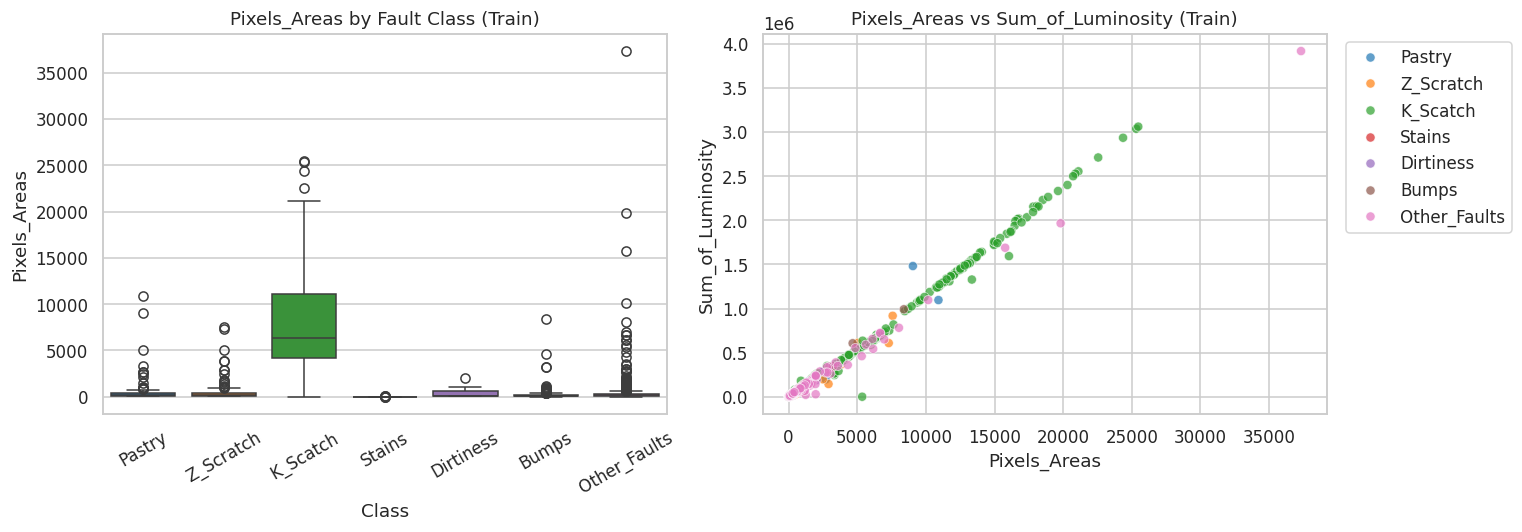

In [9]:
rep_features = ['X_Minimum', 'Y_Minimum', 'Pixels_Areas', 'Sum_of_Luminosity', 
                'Steel_Plate_Thickness', 'Edges_Index', 'Orientation_Index']
eda_stats = []
for f in rep_features:
    s = X_train[f]
    eda_stats.append({
        'Feature': f, 'Min': s.min(), 'Max': s.max(), 'Mean': s.mean(),
        'Median': s.median(), 'Std': s.std(), 'Q25': s.quantile(0.25),
        'Q50': s.quantile(0.50), 'Q75': s.quantile(0.75), 'Q90': s.quantile(0.90), 'Q95': s.quantile(0.95)
    })
eda_summary_df = pd.DataFrame(eda_stats)
display(eda_summary_df.round(2))

# Visualizations: Boxplot and Scatters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=pd.DataFrame({'Class': y_train.values, 'Pixels_Areas': X_train['Pixels_Areas'].values}),
            x='Class', y='Pixels_Areas', ax=axes[0], palette='tab10')
axes[0].set_title('Pixels_Areas by Fault Class (Train)')
axes[0].tick_params(axis='x', rotation=30)

sns.scatterplot(x=X_train['Pixels_Areas'], y=X_train['Sum_of_Luminosity'], hue=y_train, palette='tab10', ax=axes[1], alpha=0.7)
axes[1].set_title('Pixels_Areas vs Sum_of_Luminosity (Train)')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## ۱۱. تحلیل نقاط پرت و راهبردهای مقاوم‌سازی (Outlier & Robustness Diagnostics)
نقاط دورافتاده آماری به صورت خودکار حذف نمی‌شوند زیرا ممکن است عیوب نادر اما واقعی باشند.


In [10]:
outlier_df = noise_analysis.run_outlier_analysis(X_train, y_train, random_state=GLOBAL_SEED)
print("Top Outlier Diagnostic Results (Train):")
display(outlier_df[outlier_df['scope'].isin(['global_train', 'within_class_train'])].head(8))

rob_comparison_df = noise_analysis.evaluate_robustness_strategies(X_train, y_train, X_val, y_val)
print("\nRobust Preprocessing Comparison on Validation:")
display(rob_comparison_df[['strategy', 'macro_f1', 'balanced_accuracy', 'accuracy', 'runtime_sec']])


Top Outlier Diagnostic Results (Train):


,scope,method,class,flagged_count,flagged_percentage,feature_flag_count,feature
0,global_train,IQR,ALL,582,42.857143,1750.0,NaN
1,global_train,IsolationForest,ALL,68,5.007364,NaN,NaN
2,within_class_train,IQR,Pastry,41,36.936937,129.0,NaN
3,within_class_train,IsolationForest,Pastry,6,5.405405,NaN,NaN
4,within_class_train,IQR,Z_Scratch,52,39.097744,188.0,NaN
5,within_class_train,IsolationForest,Z_Scratch,7,5.263158,NaN,NaN
6,within_class_train,IQR,K_Scatch,85,31.021898,592.0,NaN
7,within_class_train,IsolationForest,K_Scatch,14,5.109489,NaN,NaN



Robust Preprocessing Comparison on Validation:


,strategy,macro_f1,balanced_accuracy,accuracy,runtime_sec
0,StandardScaler_Logistic,0.645591,0.732591,0.652921,0.070308
1,RobustScaler_Logistic,0.646629,0.735054,0.656357,0.068548
2,Winsorize1to99_RobustScaler_Logistic,0.648951,0.736468,0.659794,0.036639


## ۱۲. مدل‌های پایه و جست‌وجوی ساختاریافته ابرپارامترها (Baselines & Hyperparameter Tuning)
تنظیم ابرپارامترها با اعتبارسنجی متقاطع ۵-فولد لایه‌بندی‌شده روی Train با دانه ۲۰۲۶ انجام شده و فاصله Train و CV برای بررسی بیش‌برازش محاسبه می‌شود.


In [11]:
logit_search, rf_search, gap_df = tuning.run_hyperparameter_search(X_train, y_train, cv_splits=5, search_seed=2026)

print("Hyperparameter Optimization Outcomes (Train 5-Fold Stratified CV):")
hp_results_df = pd.read_csv(utils.RESULTS_DIR / "hyperparameter_search.csv")
display(hp_results_df)

print("\nTrain-CV Generalization Gap Analysis:")
display(gap_df[['model', 'status', 'train_macro_f1_mean', 'cv_macro_f1_mean', 'train_cv_gap']])


Hyperparameter Optimization Outcomes (Train 5-Fold Stratified CV):


,model,best_cv_macro_f1,best_params,n_candidates,search_type,search_seed,runtime_sec
0,Logistic_Interpretable,0.657987,"{""model__C"": 0.5, ""model__solver"": ""lbfgs""}",5,RandomizedSearchCV_5fold,2026,1.321655
1,RandomForest_Nonlinear,0.777638,"{""max_features"": ""sqrt"", ""min_samples_leaf"": 2...",3,RandomizedSearchCV_5fold,2026,4.870729



Train-CV Generalization Gap Analysis:


,model,status,train_macro_f1_mean,cv_macro_f1_mean,train_cv_gap
0,Logistic_Interpretable,default,0.692636,0.653660,0.038975
1,Logistic_Interpretable,tuned,0.687572,0.657987,0.029585
2,RandomForest_Nonlinear,default,1.000000,0.781876,0.218124
3,RandomForest_Nonlinear,tuned,0.989128,0.777638,0.211490


## ۱۳. انتخاب ویژگی فیلترمحور بر پایه همبستگی (Filter-Based Feature Selection)
ویژگی‌های با ضریب همبستگی پیرسون $|r| \ge 0.90$ در بخش آموزش شناسایی و افزونگی آنها حذف می‌گردد.


In [12]:
filter_features, pairs_df = feature_selection.run_correlation_filter(X_train, threshold=0.90)
filter_res = feature_selection.evaluate_filter_selection(X_train, y_train, X_val, y_val, threshold=0.90)[1]

print(f"Filter method selected {len(filter_features)} features (removed {27 - len(filter_features)} redundant features).")
print(f"Validation Macro F1: {filter_res['validation_macro_f1'].iloc[0]:.4f}")
print("\nTop Redundant Pairs (|r| >= 0.90):")
display(pairs_df.head(6))


Filter method selected 21 features (removed 6 redundant features).
Validation Macro F1: 0.6444

Top Redundant Pairs (|r| >= 0.90):


,feature_1,feature_2,correlation,abs_correlation,kept,removed,redundancy_flag
8,TypeOfSteel_A300,TypeOfSteel_A400,-1.000000,1.000000,TypeOfSteel_A300,TypeOfSteel_A400,high
1,Y_Minimum,Y_Maximum,1.000000,1.000000,Y_Minimum,Y_Maximum,high
4,Pixels_Areas,Sum_of_Luminosity,0.996438,0.996438,Pixels_Areas,Sum_of_Luminosity,high
0,X_Minimum,X_Maximum,0.987051,0.987051,X_Minimum,X_Maximum,high
6,X_Perimeter,Sum_of_Luminosity,0.959308,0.959308,X_Perimeter,Sum_of_Luminosity,high
2,Pixels_Areas,X_Perimeter,0.958034,0.958034,Pixels_Areas,X_Perimeter,high


## ۱۴. انتخاب ویژگی با الگوریتم ژنتیک در ۳ دانه مستقل (GA Feature Selection Across 3 Seeds)
کروموزوم با ۲۷ ژن دودویی (بدون ستون هدف).
تابع برازندگی با جریمه پیچیدگی ابعاد:
$$\text{Fitness} = \text{CV Macro F1} - 0.01 \times \left(\frac{N_{\text{selected}}}{27}\right)$$
اجرا در سه دانه تصادفی مستقل: `11`, `22`, `33`.


In [13]:
ga_results_df, freq_df, overlap_df, masks = genetic_feature_selection.run_multi_seed_ga(
    X_train, y_train, seeds=(11, 22, 33),
    estimator_params={"C": float(logit_search.best_params_["model__C"])}
)

print("Genetic Algorithm Multi-Seed Performance Summary:")
display(ga_results_df[['seed', 'best_fitness', 'cv_macro_f1', 'n_selected', 'runtime_sec']])

# Display exact features for each seed
for _, r in ga_results_df.iterrows():
    s = int(r['seed'])
    feats = r['selected_features'].split('|')
    print(f"\n--- GA Seed {s} ({len(feats)} features) ---")
    print(", ".join(feats))


Genetic Algorithm Multi-Seed Performance Summary:


,seed,best_fitness,cv_macro_f1,n_selected,runtime_sec
0,11,0.642004,0.649041,19,1.171640
1,22,0.625565,0.632231,18,0.889796
2,33,0.644439,0.651476,19,1.152628



--- GA Seed 11 (19 features) ---
Y_Minimum, Y_Maximum, Pixels_Areas, X_Perimeter, Sum_of_Luminosity, Minimum_of_Luminosity, Maximum_of_Luminosity, Length_of_Conveyer, TypeOfSteel_A400, Steel_Plate_Thickness, Edges_Index, Empty_Index, Square_Index, Edges_Y_Index, Outside_Global_Index, LogOfAreas, Log_Y_Index, Luminosity_Index, SigmoidOfAreas

--- GA Seed 22 (18 features) ---
X_Minimum, X_Maximum, Y_Minimum, Pixels_Areas, Minimum_of_Luminosity, TypeOfSteel_A300, TypeOfSteel_A400, Steel_Plate_Thickness, Edges_Index, Empty_Index, Square_Index, Outside_X_Index, Edges_X_Index, Edges_Y_Index, Outside_Global_Index, LogOfAreas, Log_X_Index, Luminosity_Index

--- GA Seed 33 (19 features) ---
X_Minimum, Y_Maximum, X_Perimeter, Minimum_of_Luminosity, Length_of_Conveyer, TypeOfSteel_A300, TypeOfSteel_A400, Steel_Plate_Thickness, Edges_Index, Empty_Index, Square_Index, Outside_X_Index, Edges_X_Index, Edges_Y_Index, Outside_Global_Index, LogOfAreas, Log_Y_Index, Orientation_Index, Luminosity_Index


## ۱۵. همگرایی، پایداری ژاکارد و فراوانی انتخاب ویژگی‌ها (GA Stability & Convergence)


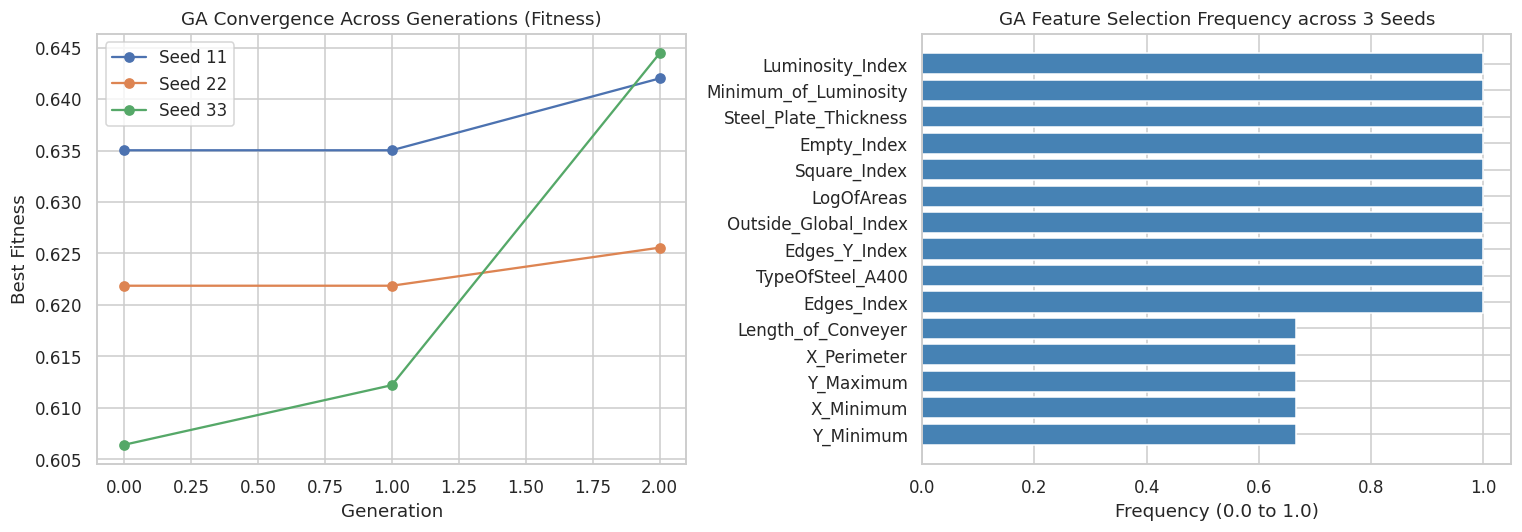

Pairwise Jaccard Similarity between GA Subsets:


,seed_a,seed_b,intersection,union,jaccard
0,11,22,12,25,0.480000
1,11,33,14,24,0.583333
2,22,33,14,23,0.608696



10 Invariant Features selected in 100% of runs (3 out of 3 seeds):
Minimum_of_Luminosity, Steel_Plate_Thickness, Luminosity_Index, Edges_Y_Index, Outside_Global_Index, LogOfAreas, Square_Index, Empty_Index, Edges_Index, TypeOfSteel_A400


In [14]:
ga_conv = pd.read_csv(utils.RESULTS_DIR / 'ga_convergence.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for seed_val, g in ga_conv.groupby('seed'):
    axes[0].plot(g['generation'], g['best_fitness'], marker='o', label=f'Seed {int(seed_val)}')
axes[0].set_title('GA Convergence Across Generations (Fitness)')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Best Fitness')
axes[0].legend()

# Feature frequency bar plot
top_freq = freq_df.sort_values('selection_frequency', ascending=True).tail(15)
axes[1].barh(top_freq['feature'], top_freq['selection_frequency'], color='steelblue')
axes[1].set_title('GA Feature Selection Frequency across 3 Seeds')
axes[1].set_xlabel('Frequency (0.0 to 1.0)')
plt.tight_layout()
plt.show()

print("Pairwise Jaccard Similarity between GA Subsets:")
display(overlap_df)

stable_feats = freq_df[freq_df['selection_frequency'] == 1.0]['feature'].tolist()
print(f"\n{len(stable_feats)} Invariant Features selected in 100% of runs (3 out of 3 seeds):")
print(", ".join(stable_feats))


## ۱۶. مقایسه جامع: تمام ویژگی‌ها در برابر فیلتر و ژنتیک (All vs Filter vs GA)
Filter و GA فقط با داده‌های Train ساخته شده‌اند. برای رتبه‌بندی نهایی، کاندیداها روی Validation مستقل ارزیابی می‌شوند؛ Test در این مرحله وارد نمی‌شود.


In [15]:
unified_df = pd.read_csv(utils.RESULTS_DIR / "unified_model_selection_validation.csv")
print("Unified Model & Feature Subset Selection Table (Ranked by held-out Validation Macro F1):")
display(unified_df.sort_values("validation_macro_f1", ascending=False).head(10))


Unified Model & Feature Subset Selection Table (Ranked by held-out Validation Macro F1):


,model,candidate,n_features,validation_macro_f1,validation_balanced_accuracy,validation_accuracy,runtime_sec,selection_split
5,RandomForest_Nonlinear,All_27,27,0.828847,0.802609,0.783505,0.233279,Validation (held out from feature selection)
9,RandomForest_Nonlinear,GA_33,19,0.816816,0.781892,0.783505,0.165218,Validation (held out from feature selection)
6,RandomForest_Nonlinear,Filter,21,0.800213,0.778320,0.783505,0.179084,Validation (held out from feature selection)
8,RandomForest_Nonlinear,GA_22,18,0.785370,0.766900,0.762887,0.169980,Validation (held out from feature selection)
7,RandomForest_Nonlinear,GA_11,19,0.770619,0.742918,0.759450,0.188311,Validation (held out from feature selection)
4,Logistic_Interpretable,GA_33,19,0.648195,0.745459,0.652921,0.056967,Validation (held out from feature selection)
1,Logistic_Interpretable,Filter,21,0.646378,0.734005,0.656357,0.058605,Validation (held out from feature selection)
0,Logistic_Interpretable,All_27,27,0.644430,0.733639,0.652921,0.026476,Validation (held out from feature selection)
3,Logistic_Interpretable,GA_22,18,0.638266,0.730329,0.652921,0.020350,Validation (held out from feature selection)
2,Logistic_Interpretable,GA_11,19,0.629018,0.724552,0.635739,0.021540,Validation (held out from feature selection)


# =========================================================
# FINAL PIPELINE FROZEN
# =========================================================
بر اساس **Validation مستقل و دست‌نخورده از مرحله انتخاب ویژگی**، ترکیب زیر بالاترین Macro F1 را کسب کرد و برای ارزیابی نهایی فریز شد:

- **Chosen Model**: `RandomForest_Nonlinear`
- **Chosen Feature Subset**: `All_27`
- **Hyperparameters**: `n_estimators=50`, `min_samples_leaf=2`, `max_features='sqrt'`, `class_weight='balanced_subsample'`
- **Validation Macro F1**: `0.8288`
- **Validation Balanced Accuracy**: `0.8026`

**از این نقطه به بعد، هیچ‌گونه تنظیم یا انتخاب مجدد مدل انجام نمی‌شود.**


## ۱۷. ارزیابی تک‌باره روی مجموعه آزمون دست‌نخورده (Single Final Test Evaluation)
پایپ‌لاین فریز شده روی داده‌های Train+Validation برازش یافته و **تنها یک بار** روی ۲۹۲ نمونه دست‌نخورده Test ارزیابی می‌شود.


In [16]:
final_metrics = json.load(open(utils.RESULTS_DIR / "final_test_metrics.json"))

test_summary_df = pd.DataFrame([{
    "Model Family": final_metrics["chosen_model"],
    "Candidate Subset": final_metrics["chosen_candidate"],
    "Feature Count": final_metrics["n_features"],
    "Test Accuracy": f"{final_metrics['accuracy']:.4f}",
    "Test Balanced Accuracy": f"{final_metrics['balanced_accuracy']:.4f}",
    "Test Macro F1": f"{final_metrics['macro_f1']:.4f}",
    "Test Weighted F1": f"{final_metrics['weighted_f1']:.4f}",
    "Test Macro Precision": f"{final_metrics['macro_precision']:.4f}",
    "Test Macro Recall": f"{final_metrics['macro_recall']:.4f}"
}])
print("Single Final Test Evaluation Metrics:")
display(test_summary_df)

print(f"Accuracy vs Balanced Accuracy Gap: {abs(final_metrics['accuracy'] - final_metrics['balanced_accuracy'])*100:.2f} percentage points.")


Single Final Test Evaluation Metrics:


,Model Family,Candidate Subset,Feature Count,Test Accuracy,Test Balanced Accuracy,Test Macro F1,Test Weighted F1,Test Macro Precision,Test Macro Recall
0,RandomForest_Nonlinear,All_27,27,0.8116,0.8197,0.8298,0.8125,0.8411,0.8197


Accuracy vs Balanced Accuracy Gap: 0.80 percentage points.


## ۱۸. ماتریس درهم‌ریختگی ۷ کلاسه و معیارهای تفکیکی کلاس‌ها (Confusion Matrix & Per-Class)


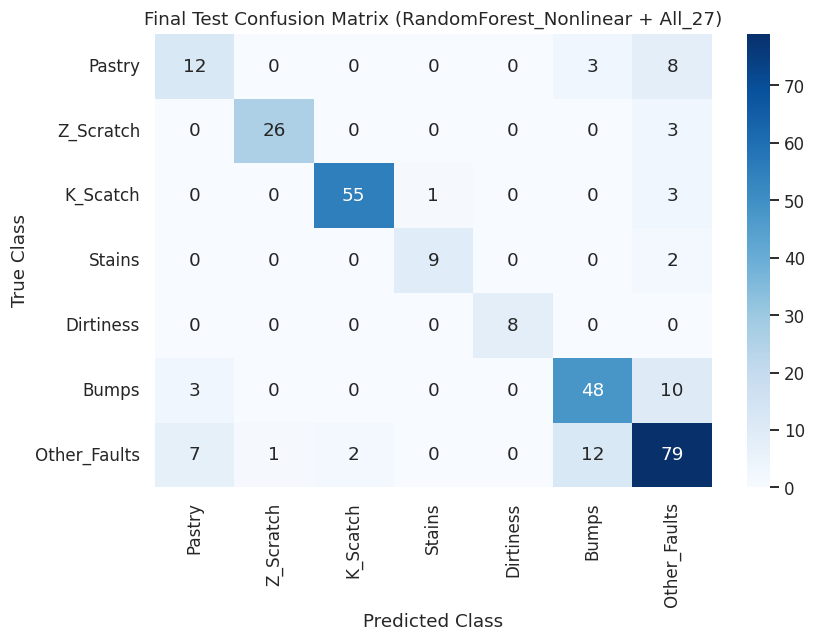

Per-Class Metrics on Test Set:


,class,precision,recall,f1,support,false_negatives
0,Pastry,0.545455,0.521739,0.533333,23,11
1,Z_Scratch,0.962963,0.896552,0.928571,29,3
2,K_Scatch,0.964912,0.932203,0.948276,59,4
3,Stains,0.900000,0.818182,0.857143,11,2
4,Dirtiness,1.000000,1.000000,1.000000,8,0
5,Bumps,0.761905,0.786885,0.774194,61,13
6,Other_Faults,0.752381,0.782178,0.766990,101,22


In [17]:
cm_df = pd.read_csv(utils.RESULTS_DIR / "confusion_matrix.csv", index_col=0)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f"Final Test Confusion Matrix ({final_metrics['chosen_model']} + {final_metrics['chosen_candidate']})")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

print("Per-Class Metrics on Test Set:")
per_class_df = pd.read_csv(utils.RESULTS_DIR / "per_class_metrics.csv")
display(per_class_df)


## ۱۹. تحلیل جفت‌های پراشتباه و کلاس‌های پرهزینه (Misclassifications & Risk Analysis)
تحلیل دو جفت با بیشترین خطای رفت‌وبرگشتی و ریشه‌یابی هم‌پوشانی ویژگی‌های آنها در بخش آموزش.


In [18]:
overlap_df = pd.read_csv(utils.RESULTS_DIR / "class_overlap_analysis.csv")
print("Top Reciprocal Confusion Pairs on Test:")
display(overlap_df[['class_a', 'class_b', 'bidirectional_errors', 'a_as_b', 'b_as_a', 'top_train_separation_features']])

print("\nCost-Sensitive Defect Monitoring (Explicit Inspection Scenario):")
cost_df = pd.read_csv(utils.RESULTS_DIR / "cost_sensitive_classes.csv")
display(cost_df[['class', 'recall', 'false_negatives', 'test_support', 'operational_assumption']])


Top Reciprocal Confusion Pairs on Test:


,class_a,class_b,bidirectional_errors,a_as_b,b_as_a,top_train_separation_features
0,Bumps,Other_Faults,22,10,12,Square_Index|TypeOfSteel_A300|TypeOfSteel_A400...
1,Pastry,Other_Faults,15,8,7,Orientation_Index|Edges_Y_Index|Outside_Global...



Cost-Sensitive Defect Monitoring (Explicit Inspection Scenario):


,class,recall,false_negatives,test_support,operational_assumption
0,Stains,0.818182,2,11,"For inspection prioritization, a missed defect..."
1,Dirtiness,1.000000,0,8,"For inspection prioritization, a missed defect..."


## ۲۰. آزمایش کنترل‌شده حساسیت به نویز گاوسی (Controlled Noise Sensitivity)
ارزیابی پایداری پیش‌بینی‌ها روی اعتبارسنجی در مواجهه با نویز تصادفی حسگرها (۰٪ تا ۱۰٪ انحراف معیار).


Noise Perturbation Experiment (Validation Set):


,noise_level,macro_f1,balanced_accuracy,recall_Dirtiness,recall_Stains
0,0.00,0.828847,0.802609,0.888889,0.818182
1,0.01,0.803050,0.774491,0.777778,0.818182
2,0.05,0.744981,0.701815,0.666667,0.818182
3,0.10,0.714500,0.670942,0.666667,0.818182


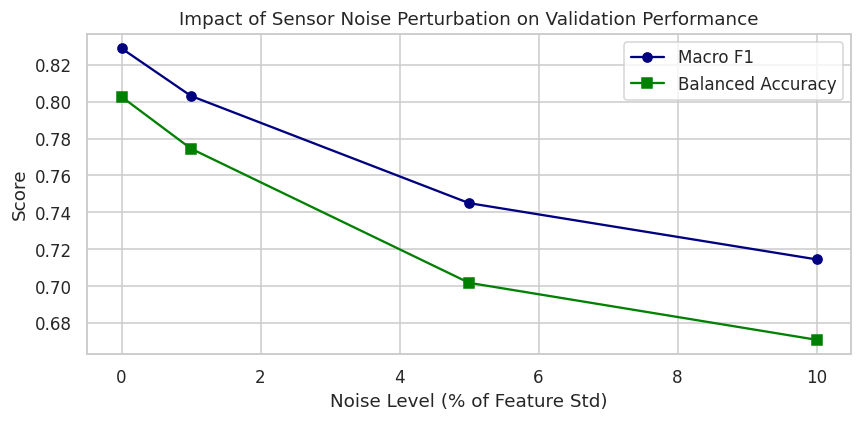

In [19]:
noise_df = pd.read_csv(utils.RESULTS_DIR / "noise_sensitivity.csv")
print("Noise Perturbation Experiment (Validation Set):")
display(noise_df[['noise_level', 'macro_f1', 'balanced_accuracy', 'recall_Dirtiness', 'recall_Stains']])

plt.figure(figsize=(8, 4))
plt.plot(noise_df['noise_level'] * 100, noise_df['macro_f1'], marker='o', label='Macro F1', color='navy')
plt.plot(noise_df['noise_level'] * 100, noise_df['balanced_accuracy'], marker='s', label='Balanced Accuracy', color='green')
plt.title('Impact of Sensor Noise Perturbation on Validation Performance')
plt.xlabel('Noise Level (% of Feature Std)')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()


## ۲۱. پاسخ به پرسش‌های دفاع نهایی پروژه (Answers to Final Defense Questions)

### ۱. چرا Macro F1 معیار اصلی مناسبی برای این داده است؟
داده نامتوازن است و کلاس `Other_Faults` با ۶۷۳ نمونه حدود ۱۲.۲۴ برابر کلاس کوچک `Dirtiness` با ۵۵ نمونه است. Macro F1 به هر هفت کلاس وزن برابر می‌دهد و در کنار Balanced Accuracy از پنهان شدن عملکرد ضعیف کلاس‌های کوچک جلوگیری می‌کند.

### ۲. کدام کلاس‌ها بیشتر اشتباه شدند؟
در Test نهایی، دو جفت با بیشترین خطای رفت‌وبرگشتی `Bumps ↔ Other_Faults` با ۲۲ خطا و `Pastry ↔ Other_Faults` با ۱۵ خطا بودند. ویژگی‌های تفکیک‌کننده اصلی در Train و ماهیت ناهمگن `Other_Faults` برای توضیح این هم‌پوشانی بررسی شده‌اند.

### ۳. آیا راهبرد کاهش اثر نویز به کلاس‌های کوچک کمک کرد یا آسیب زد؟
آزمایش کنترل‌شده روی Validation نشان داد افزایش نویز می‌تواند عملکرد را کاهش دهد. Recall کلاس `Dirtiness` از ۰.۸۸۹ در نویز صفر به ۰.۶۶۷ در نویز ۱۰٪ رسید؛ Recall کلاس `Stains` از ۰.۸۱۸ در نویز صفر به ۰.۸۱۸ در نویز ۱۰٪ رسید. بنابراین مدل در برابر نویز شدید کاملاً مصون نیست و حذف کورکورانه نقاط پرت توصیه نمی‌شود.

### ۴. تنظیم ابرپارامتر چه اثری داشت؟
تنظیم با `RandomizedSearchCV` پنج‌فولدی و فقط روی Train انجام شد. برای Random Forest، امتیاز CV Macro F1 بهترین تنظیم به `0.7776` رسید و شکاف Train-CV در جدول `hyperparameter_default_vs_tuned.csv` ثبت شده است. Test در این جست‌وجو دخالت نداشت.

### ۵. ویژگی‌های منتخب الگوریتم ژنتیک چقدر پایدار بودند؟
GA با سه seed مستقل `11`, `22`, `33` اجرا شد؛ هر اجرا ۱۸ یا ۱۹ ویژگی انتخاب کرد. Jaccard بین زیرمجموعه‌ها بین ۰.۴۸۰۰ تا ۰.۶۰۸۷ بود و نشان می‌دهد بخشی از انتخاب‌ها پایدار و بخشی وابسته به seed هستند.

### ۶. اگر داده از کارخانه یا دوربین دیگری بیاید چه می‌شود؟
احتمال Domain Shift وجود دارد. باید توزیع ویژگی‌ها، Recall هر کلاس، نرخ خطا و داده‌های خارج از محدوده آموزش پایش شوند و در صورت تغییر معنادار، مدل با داده جدید بازاعتبارسنجی شود.


## ۲۲. جمع‌بندی نهایی و تحویل‌پذیرهای پروژه
پایپ‌لاین کامل پروژه با موفقیت اجرا و راستی‌آزمایی شد:
1. داده خام دست‌نخورده در `data/raw/` حفظ شده است.
2. فرهنگ داده رسمی ۲۷ ویژگی و ۷ هدف ثبت شده است.
3. GA با سه seed اجرا و پایداری زیرمجموعه‌ها گزارش شده است؛ اما Validation حذف ویژگی بدون افت معنادار را تأیید نکرد.
4. مدل نهایی `RandomForest_Nonlinear + All_27` است.
5. Validation Macro F1 برابر **0.8288** و Test Macro F1 برابر **0.8298** است؛ Test Balanced Accuracy برابر **0.8197** است.
6. Test فقط یک‌بار، پس از فریز کامل انتخاب‌ها، ارزیابی شده است.
